# App. F: does the learning objective change which correlators the network selects?

This notebook reproduces `Plots/Fig_F1.pdf` (`fig:task_dependence`, Fig. 20, App. F 6 "Task
dependence of the learned descriptors"). It compares
the branches TetrisCNN selects for phase classification (main text, Figs. 4-6) against
the branches the same front end selects when trained instead to regress the two
experimental tuning parameters separately, $\delta$ alone and $\Omega$ alone, via the
prediction-divergence method (App. E 2). All three runs use the Ising dataset.

### The question

The main text argues that the correlators a network settles on reflect the task it was
set, not only the underlying physics: classification favors sharp phase indicators while
regression favors smoothly-varying ones, so "what the network used" is not automatically
"the order parameter." This notebook makes that claim concrete rather than asserting it.

Classification and $\delta$-regression both collapse onto the same single-site branch
$z[\blacksquare]$: the Z-magnetization/density crossover that separates the two classes
is also a good proxy for $\delta$ itself, so both tasks are satisfied by the same
correlator. $\Omega$-regression is the sharper test. It gives that branch exactly zero
weight and instead spreads its markedly weaker signal over two nearest-neighbor branches
and one $2\times2$ branch, because predicting $\Omega$ from $Z$-basis snapshots has no
single-site proxy to fall back on.

Each column below is laid out identically: the top row (a,d,g) plots the classifier's
softmax probability of class 0 for column 1, or the ground-truth regression target for
columns 2-3, against sweep time; the middle row (b,e,h) plots branch activations against
the same time axis; the bottom row (c,f,i) plots branch activations against training
epoch instead.

### What it reads

Trained checkpoints under `Plots_data/App_F_data/models/Ising_{CLF,PDM_Delta,PDM_Omega}/`
(`config.json`, `metrics.json`, `net1.pt`, `net2.pt`); no retraining happens in this
notebook. Those three runs were retrained after fixing a batch-size-dependent bug in the
L1 penalty computation that had erroneously scaled the effective penalty by
`batch_size`. Removing that factor meant $\lambda_{\max}$ had to be raised by
$\approx\log_{10}(64)$ to recover the same branch selection the pre-fix runs had shown,
landing the penalty ramp recorded in these checkpoints at $\lambda_{\min}=10^{-3}$,
$\lambda_{\max}=10^{1}$.


In [1]:
import os

from tetriscnn import PAPER_MPLSTYLE
from tetriscnn.models import ShapeAdaptiveConvNet, SmallModel
from tetriscnn.utils import (
    AttrDict, load_json, DEVICE, kernel_to_latex_pattern
)
from tetriscnn.datasets import create_datasets

from tetriscnn.colors import COLORS, colors

from pathlib import Path
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Paths below (Plots_data/ in, Plots/ out) are relative to the repository root;
# move there so the notebook runs the same from the root or from notebooks/.
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))
Path("Plots/SVG").mkdir(parents=True, exist_ok=True)

### Loading and running the three checkpoints

The five helpers below mirror the loaders used throughout the paper-figure notebooks
(see `FiguresApp_F_lambdamax.ipynb`): `_load_config_from_folder` and `_load_metrics_from_folder` read
back a run's `config.json`/`metrics.json` into the `AttrDict` the training code uses,
applying the same stride-compatibility fix for kernel specs recorded before the stride
field existed. `_load_model_and_datasets` rebuilds `net1`/`net2` from that config and
loads their trained weights; `_run_inference` pushes the full validation split through
both networks in a single batch to recover the bottleneck activations `z` and the
network's raw output. `_branch_activations_vs_time` then reduces `z` to a
snapshot-averaged curve per branch against the unique sweep times, exactly as needed for
the middle row of the final figure.


In [2]:
def _load_config_from_folder(seed_folder: Path) -> AttrDict:
    cfg_path = seed_folder / "config.json"
    if not cfg_path.exists():
        raise FileNotFoundError(f"No config.json found in {seed_folder}")
    cf = AttrDict()
    cf.update(load_json(str(seed_folder), "config.json"))
    for k in range(len(cf.kernels)):          # stride compatibility fix
        if len(cf.kernels[k]) < 5:
            cf.kernels[k].append(1)
    cf.logdir = str(seed_folder)
    return cf

In [3]:
def _load_metrics_from_folder(seed_folder: Path) -> dict:
    cfg_path = seed_folder / "metrics.json"
    if not cfg_path.exists():
        raise FileNotFoundError(f"No metrics.json found in {seed_folder}")
    return load_json(str(seed_folder), "metrics.json")

In [4]:
def _load_model_and_datasets(cf, load_path):
    cf.logdir = str(load_path)
    cf.seed_folder = str(load_path)
    cf.return_all_data = False
    train_dataset, val_dataset = create_datasets(cf)

    in_channels = train_dataset[0][0].shape[0]
    net2_dims   = [len(cf.kernels), 32, 16, train_dataset.output_dim]

    net1 = ShapeAdaptiveConvNet(
        in_channels=in_channels, kernels=cf.kernels, equivariant=cf.equivariant,
        hidden_size=cf.hidden_size, init=cf.init, device=DEVICE
    ).to(DEVICE)
    net2 = SmallModel(net2_dims, device=DEVICE).to(DEVICE)

    net1.load_state_dict(torch.load(load_path / "net1.pt", map_location=DEVICE))
    net2.load_state_dict(torch.load(load_path / "net2.pt", map_location=DEVICE))

    net1.eval(); net2.eval()
    return net1, net2, val_dataset

In [5]:
def _run_inference(net1, net2, val_dataset):
    val_loader = DataLoader(
        val_dataset, batch_size=len(val_dataset),
        shuffle=False, num_workers=0, pin_memory=False
    )
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE).view(-1, val_loader.dataset[0][1].shape[0])
            z   = net1(x)
            out = net2(z)
    return z.cpu(), out.cpu()

In [6]:
def _branch_activations_vs_time(cf, val_dataset, z):
    """Per-branch snapshot-averaged bottleneck activation vs. unique sweep time."""
    mu, sigma = [], []
    for k in range(len(cf.kernels)):
        mu_k, sig_k = val_dataset.snapshot_average(z[:, k].to(DEVICE), output=False)
        mu.append(mu_k)
        sigma.append(sig_k)
    mu    = np.array(mu).T
    sigma = np.array(sigma).T
    times = val_dataset.unique_times.cpu()
    return times, mu, sigma

## Load the three Ising models

`Ising_CLF`: phase classification (partition task, same seed/$\lambda_{\max}$ as
main-text Fig. 4(b,c)). `Ising_PDM_Delta` / `Ising_PDM_Omega`: prediction-divergence
regression trained to predict $\delta$ or $\Omega$ **alone** (not the joint
$(\delta,\Omega)$ regression used for the main-text transition estimate, see App. E),
which separates out which branches each physical field individually pulls in.


In [7]:
basepath_CLF   = Path("Plots_data/App_F_data/models/Ising_CLF")
basepath_Delta = Path("Plots_data/App_F_data/models/Ising_PDM_Delta")
basepath_Omega = Path("Plots_data/App_F_data/models/Ising_PDM_Omega")

cf_CLF   = _load_config_from_folder(basepath_CLF)
cf_Delta = _load_config_from_folder(basepath_Delta)
cf_Omega = _load_config_from_folder(basepath_Omega)

net1_CLF, net2_CLF, val_CLF = _load_model_and_datasets(cf_CLF, basepath_CLF)
net1_Delta, net2_Delta, val_Delta = _load_model_and_datasets(cf_Delta, basepath_Delta)
net1_Omega, net2_Omega, val_Omega = _load_model_and_datasets(cf_Omega, basepath_Omega)

metrics_CLF   = _load_metrics_from_folder(basepath_CLF)
metrics_Delta = _load_metrics_from_folder(basepath_Delta)
metrics_Omega = _load_metrics_from_folder(basepath_Omega)

z_CLF,   out_CLF   = _run_inference(net1_CLF,   net2_CLF,   val_CLF)
z_Delta, out_Delta = _run_inference(net1_Delta, net2_Delta, val_Delta)
z_Omega, out_Omega = _run_inference(net1_Omega, net2_Omega, val_Omega)

times_CLF,   bn_mu_CLF,   bn_sigma_CLF   = _branch_activations_vs_time(cf_CLF,   val_CLF,   z_CLF)
times_Delta, bn_mu_Delta, bn_sigma_Delta = _branch_activations_vs_time(cf_Delta, val_Delta, z_Delta)
times_Omega, bn_mu_Omega, bn_sigma_Omega = _branch_activations_vs_time(cf_Omega, val_Omega, z_Omega)


 [LbC] CREATING DATASET: partition 3/27, threshold=1100.0000, total 20895 samples.

[Even Split] Found 28 time points
[Even Split] Samples per time point: min=297, max=1322, median=824.0
[Even Split] LBC class distribution: class 0=2140, class 1=18755
[Even Split] After per-time-point 70/30 split: 14613 train, 6282 val samples


times shape: 14613, labels shape: torch.Size([14613])
times shape: 6282, labels shape: torch.Size([6282])

Using standard 2-layer convolutional branches.
Note: init is unused for standard convolutions.



[Even Split] Found 28 time points
[Even Split] Samples per time point: min=297, max=1322, median=824.0
[Even Split] After per-time-point 70/30 split: 14613 train, 6282 val samples
times shape: 14613, labels shape: torch.Size([14613, 1])
times shape: 6282, labels shape: torch.Size([6282, 1])

Using standard 2-layer convolutional branches.
Note: init is unused for standard convolutions.



[Even Split] Found 28 time points
[Even Split] Samples per time point: min=297, max=1322, median=824.0
[Even Split] After per-time-point 70/30 split: 14613 train, 6282 val samples
times shape: 14613, labels shape: torch.Size([14613, 1])
times shape: 6282, labels shape: torch.Size([6282, 1])

Using standard 2-layer convolutional branches.
Note: init is unused for standard convolutions.


## Row 1 targets

- Classification: the softmax **probability of class 0**, $\mathrm{softmax}[\mathrm{logit}_0]$,
  snapshot-averaged vs. time. In a two-class problem this single bounded $[0,1]$ curve already
  behaves like the order-parameter-proportional function the network has learned, which is why we
  prefer it here over the unbounded raw logit difference (kept below as a commented-out
  alternative).
- $\delta$/$\Omega$ regression: the ground-truth tuning-parameter value (not the NN prediction),
  read directly from `val_dataset.unique_labels_unnormalized` of the same dataset object used for
  the activations above, so the time axis matches exactly.

In [8]:
probs_CLF = torch.softmax(out_CLF, dim=1)
prob0_mu_CLF, prob0_sigma_CLF = val_CLF.snapshot_average(probs_CLF[:, 0].to(DEVICE), output=False)

# --- alternative: raw logit difference instead of the softmax probability of class 0 ---
# logit_diff_CLF = out_CLF[:, 0] - out_CLF[:, 1]
# prob0_mu_CLF, prob0_sigma_CLF = val_CLF.snapshot_average(logit_diff_CLF.to(DEVICE), output=False)

labels_unique_Delta = val_Delta.unique_labels_unnormalized
labels_unique_Delta = labels_unique_Delta[:, 0] if labels_unique_Delta.ndim > 1 else labels_unique_Delta

labels_unique_Omega = val_Omega.unique_labels_unnormalized
labels_unique_Omega = labels_unique_Omega[:, 0] if labels_unique_Omega.ndim > 1 else labels_unique_Omega

## Which branches matter, per task

Read off from the final-epoch $|z_k|$ in each `metrics.json` (see appendix table): classification
and $\delta$-regression both collapse onto the single-site branch (index 0); $\Omega$-regression
gives that branch exactly zero weight and instead spreads its (much weaker) signal over the two
nearest-neighbor branches and one $2\times2$ branch (indices 1, 2, 4).

In [9]:
important_CLF   = np.zeros(len(cf_CLF.kernels));   important_CLF[0]        = 1
important_Delta = np.zeros(len(cf_Delta.kernels)); important_Delta[0]      = 1
important_Omega = np.zeros(len(cf_Omega.kernels)); important_Omega[[1, 2, 4]] = 1

### Assembling the 3x3 panel

The figure is one `subplot_mosaic` with three columns (classification,
$\delta$-regression, $\Omega$-regression) and three rows (target/probability, activation
vs. time, activation vs. epoch). Branches marked `important` in the cell above (read off
the final-epoch $|z_k|$ ranking in each `metrics.json`) are drawn opaque and slightly
thicker; the remaining, suppressed branches are drawn at reduced alpha so the eye is
drawn to the surviving branches without erasing the suppressed ones from the plot
entirely. The legend at the top is built once, from the $\Omega$-regression column's
activation panel, since all three columns share the same kernel dictionary
(`smallkernels`, 10 branches).


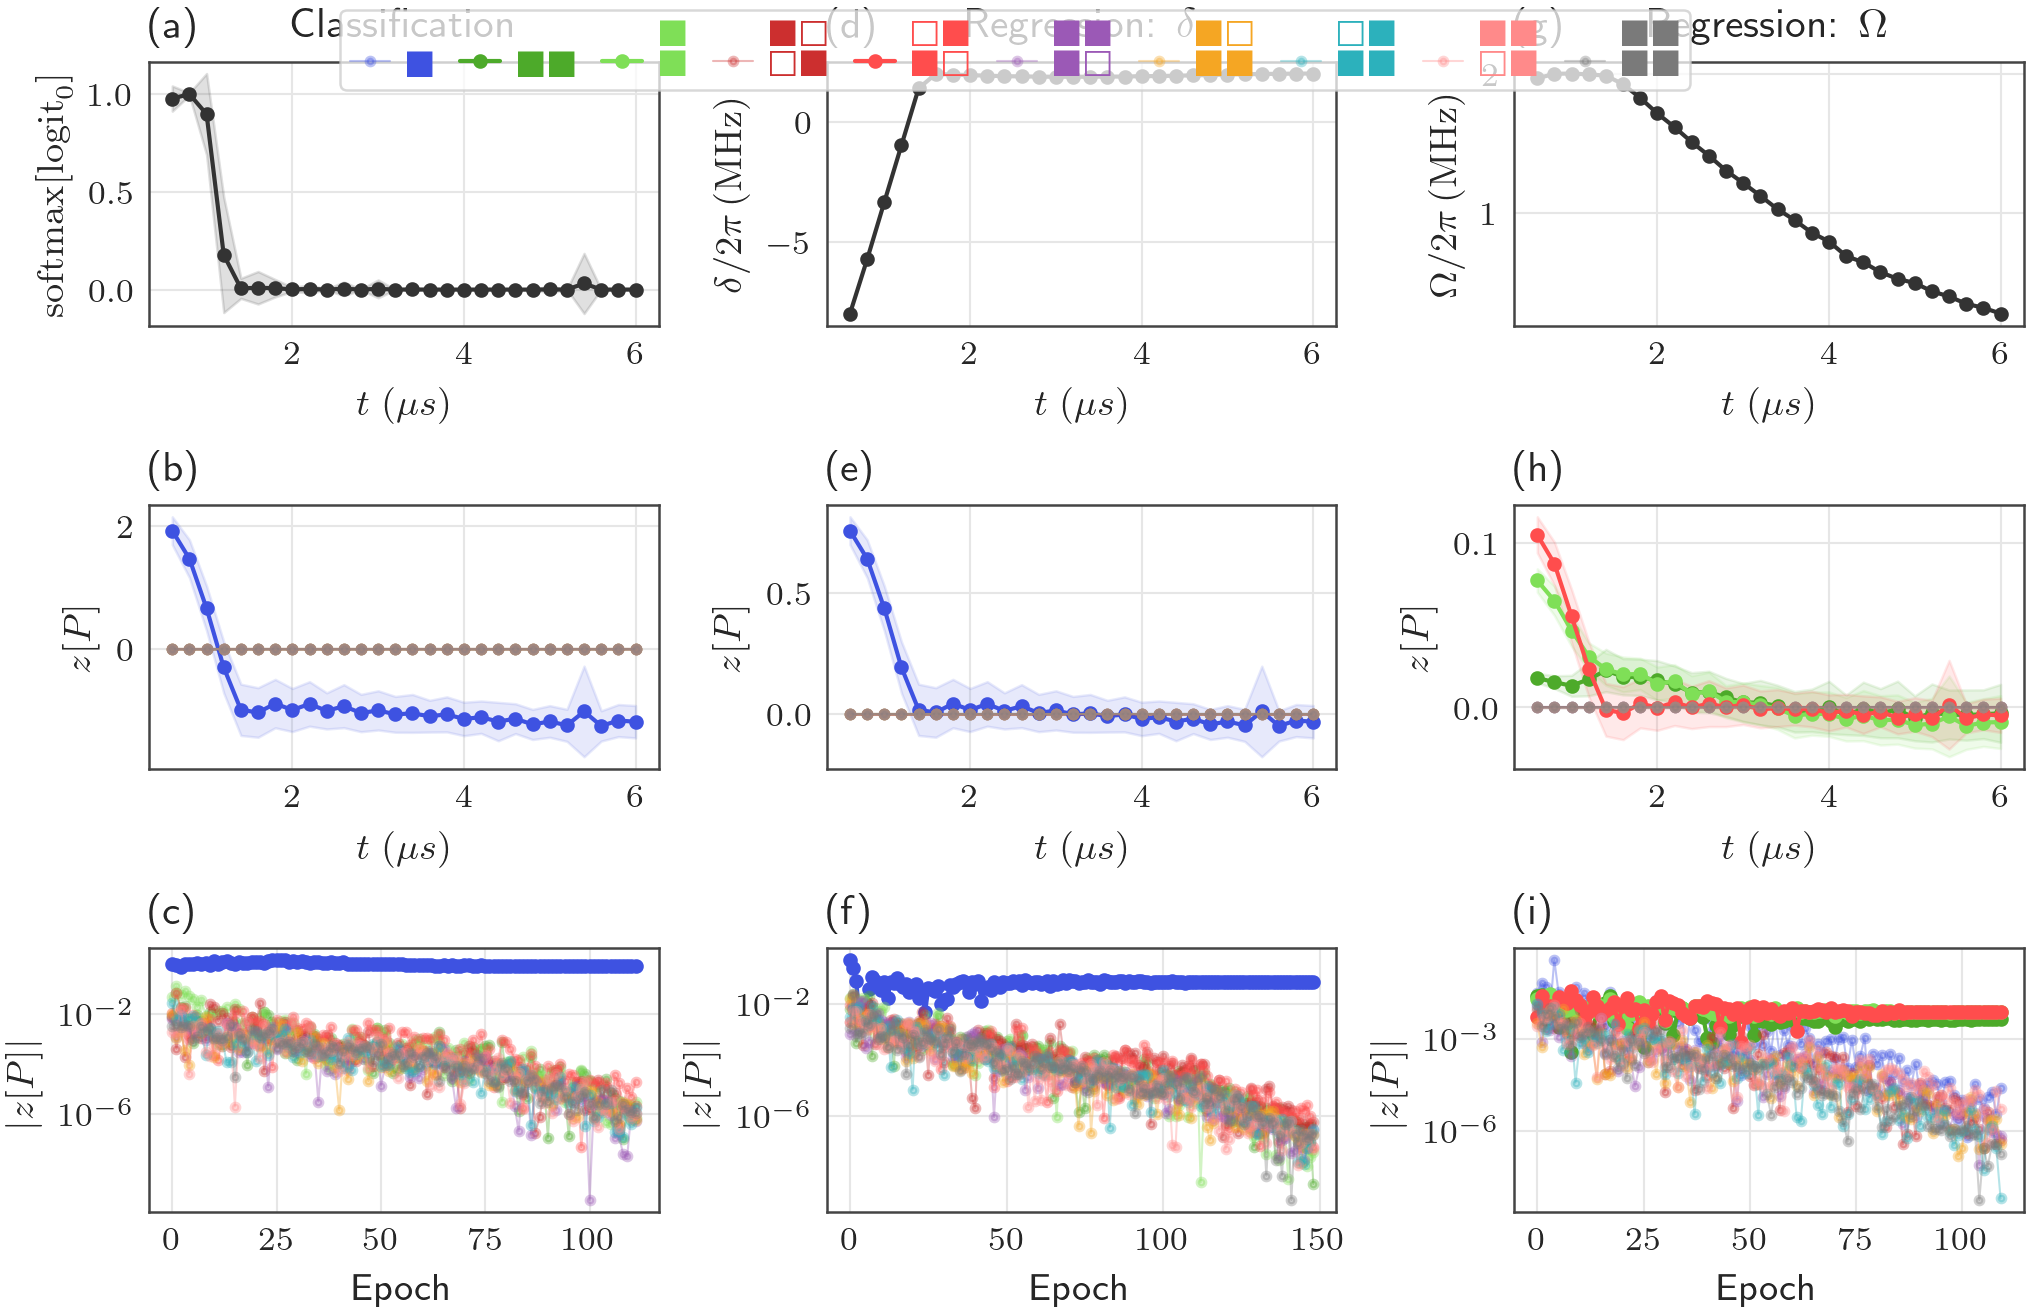

In [10]:
plt.style.use(PAPER_MPLSTYLE)

DOUBLE_WIDTH = 6.80914
golden_ratio = (1 + np.sqrt(5)) / 2

important_alpha   = 1.0
unimportant_alpha = 0.35

fig, axs = plt.subplot_mosaic(
    [["A", "D", "G"], ["B", "E", "H"], ["C", "F", "I"]],
    figsize=(DOUBLE_WIDTH, 1.05 * DOUBLE_WIDTH / golden_ratio),
    height_ratios=[0.5, 0.5, 0.5],
    constrained_layout=False,
)
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.08, top=0.87, wspace=0.45, hspace=0.55)

col_specs = [
    dict(letters=("A", "B", "C"), cf=cf_CLF, times=times_CLF, bn_mu=bn_mu_CLF, bn_sigma=bn_sigma_CLF,
         metrics=metrics_CLF, important=important_CLF, title=r"Classification"),
    dict(letters=("D", "E", "F"), cf=cf_Delta, times=times_Delta, bn_mu=bn_mu_Delta, bn_sigma=bn_sigma_Delta,
         metrics=metrics_Delta, important=important_Delta, title=r"Regression: $\delta$"),
    dict(letters=("G", "H", "I"), cf=cf_Omega, times=times_Omega, bn_mu=bn_mu_Omega, bn_sigma=bn_sigma_Omega,
         metrics=metrics_Omega, important=important_Omega, title=r"Regression: $\Omega$"),
]
panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)"]

# ------------------------------------------------------------------ row 1: target/probability vs time --
ax = axs["A"]
ax.plot(times_CLF / 1e3, prob0_mu_CLF, "o-", ms=2.5, color=COLORS["blackish"])
ax.fill_between(times_CLF / 1e3, prob0_mu_CLF - prob0_sigma_CLF,
                 prob0_mu_CLF + prob0_sigma_CLF, color=COLORS["blackish"], alpha=0.15)
ax.set_ylabel(r"$\mathrm{softmax}[\mathrm{logit}_0]$")
ax.set_xlabel(r"$t\;(\mu s)$")
ax.set_title(col_specs[0]["title"])
ax.set_title(panel_labels[0], loc="left")

ax = axs["D"]
ax.plot(times_Delta / 1e3, labels_unique_Delta, "o-", ms=2.5, color=COLORS["blackish"])
ax.set_ylabel(r"$\delta/2\pi\,(\mathrm{MHz})$")
ax.set_xlabel(r"$t\;(\mu s)$")
ax.set_title(col_specs[1]["title"])
ax.set_title(panel_labels[3], loc="left")

ax = axs["G"]
ax.plot(times_Omega / 1e3, labels_unique_Omega, "o-", ms=2.5, color=COLORS["blackish"])
ax.set_ylabel(r"$\Omega/2\pi\,(\mathrm{MHz})$")
ax.set_xlabel(r"$t\;(\mu s)$")
ax.set_title(col_specs[2]["title"])
ax.set_title(panel_labels[6], loc="left")

# --------------------------------------------------------------- row 2: activations vs time -------
for spec, letter, label_idx in zip(col_specs, ("B", "E", "H"), (1, 4, 7)):
    ax = axs[letter]
    for i in range(len(spec["cf"].kernels)):
        imp = spec["important"][i]
        ax.plot(spec["times"] / 1e3, spec["bn_mu"][:, i], color=colors[i % 10], marker="o",
                lw=1.0 if imp else 0.5, ms=2.5 if imp else 1.8,
                alpha=important_alpha if imp else unimportant_alpha,
                label=kernel_to_latex_pattern(spec["cf"].kernels[i]))
        ax.fill_between(spec["times"] / 1e3, spec["bn_mu"][:, i] - spec["bn_sigma"][:, i],
                         spec["bn_mu"][:, i] + spec["bn_sigma"][:, i], color=colors[i % 10], alpha=0.12)
    ax.set_ylabel("$z[P]$")
    ax.set_xlabel(r"$t\;(\mu s)$")
    ax.set_title(panel_labels[label_idx], loc="left")

with plt.rc_context({"text.usetex": False}):
    handles, labels = axs["H"].get_legend_handles_labels()
    legend = fig.legend(
        handles, labels, loc="upper center", 
        bbox_to_anchor=(0.5, 1.0),
        ncol=10, framealpha=0.75)
    for text, line in zip(legend.get_texts(), legend.get_lines()):
        text.set_color(line.get_color())

# ------------------------------------------------------------ row 3: training history vs epoch ----
for spec, letter, label_idx in zip(col_specs, ("C", "F", "I"), (2, 5, 8)):
    ax = axs[letter]
    bottleneck_history = np.array(
        [spec["metrics"][f"z_{k}"] for k in range(len(spec["cf"].kernels))]
    )
    for i in range(len(spec["cf"].kernels)):
        imp = spec["important"][i]
        ax.plot(np.abs(bottleneck_history[i]), color=colors[i % 10], marker="o",
                lw=1.0 if imp else 0.5, ms=2.5 if imp else 1.8,
                alpha=important_alpha if imp else unimportant_alpha)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(r"$\left|z[P]\right|$")
    ax.set_yscale("log")
    ax.set_title(panel_labels[label_idx], loc="left")

fig.savefig("Plots/Fig_F1.pdf")

## Notes

- Row (a): the classifier has no smoothly-varying ground-truth target, so we instead plot its
  softmax probability of class 0, $\mathrm{softmax}[\mathrm{logit}_0]$, to compare against the
  smooth $\delta,\Omega$ targets in columns 2-3 on the same footing. In a two-class problem this
  single bounded $[0,1]$ curve already behaves like the order-parameter-proportional function the
  network has learned. Swap in the commented-out raw-logit-difference block in the cell above if
  an unbounded decision variable is preferred instead.
- Rows (b)/(c) vs (e)/(f): $\delta$-regression closely mirrors the classifier (same dominant branch,
  index 0), consistent with $\delta$ being well approximated by the density/magnetization channel
  the classifier already uses.
- Rows (h)/(i): $\Omega$-regression gives the index-0 branch **exactly zero** weight throughout
  training and instead relies on branches 1, 2, and 4, none of which survive under classification or
  $\delta$-regression. This is the sharpest illustration of task dependence in the appendix: predicting
  $\Omega$ from $Z$-basis snapshots has no single-channel proxy available, so the network is forced
  onto a qualitatively different, and individually much weaker, combination of correlators.
- The joint $(\delta,\Omega)$ regression used for the main-text transition estimate (App. E) sits
  in between: its small residual weight on branches 1 and 2 (appendix table) is explained by this
  decomposition as coming almost entirely from the $\Omega$ arm of the joint task.